# Eksperiment 2-4 — Forma (EMA 50%)

Predikcija ishoda (Away Win / Draw / Home Win) koristeci SAMO formu tima racunatu kao Exponential Moving Average sa alpha=50% (`home_form_ema50`, `away_form_ema50`).

In [7]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from experiment_utils import save_result_v1, run_one_experiment, run, MLPClassifier


## Priprema podataka

Uzimamo samo `home_form_ema50` i `away_form_ema50` kao feature, target je `result` (-1/0/1) mapiran u klase 0/1/2 (Away/Draw/Home), isti redosled kao `class_names` iznad.

In [2]:
FEATURE_COLS = ["home_form_ema50", "away_form_ema50"]

data = pd.read_csv("../data/Processed_Project_Data/fifa_and_elo_with_ema.csv")
data = data.dropna(subset=FEATURE_COLS + ["result"])

X = data[FEATURE_COLS].values.astype(np.float32)
y = (data["result"].values + 1).astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


In [4]:
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

input_dim = X_train_tensor.shape[1]

model = MLPClassifier(input_dim=input_dim)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Epoch 50/1000 | train loss = 1.0124 | val loss = 0.9257 | val acc = 0.5955
Epoch 100/1000 | train loss = 1.0102 | val loss = 0.9288 | val acc = 0.5955
Epoch 150/1000 | train loss = 0.9962 | val loss = 0.9246 | val acc = 0.5843
Epoch 200/1000 | train loss = 0.9981 | val loss = 0.9304 | val acc = 0.5843
Epoch 250/1000 | train loss = 1.0084 | val loss = 0.9359 | val acc = 0.5787
Epoch 300/1000 | train loss = 0.9989 | val loss = 0.9359 | val acc = 0.5843
Epoch 350/1000 | train loss = 1.0064 | val loss = 0.9364 | val acc = 0.5787
Epoch 400/1000 | train loss = 1.0024 | val loss = 0.9389 | val acc = 0.5787
Epoch 450/1000 | train loss = 0.9970 | val loss = 0.9364 | val acc = 0.5787
Epoch 500/1000 | train loss = 0.9987 | val loss = 0.9327 | val acc = 0.5787
Epoch 550/1000 | train loss = 0.9961 | val loss = 0.9370 | val acc = 0.5843
Epoch 600/1000 | train loss = 0.9967 | val loss = 0.9405 | val acc = 0.5787
Epoch 650/1000 | train loss = 0.9929 | val loss = 0.9394 | val acc = 0.5730
Epoch 700/100

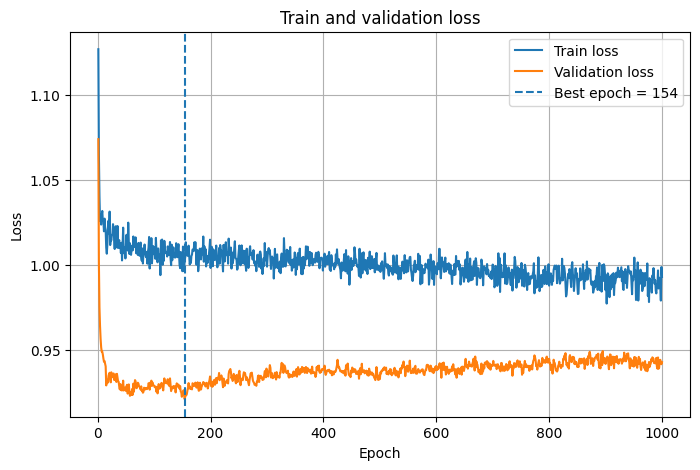

0.5135135135135135

In [5]:
run_one_experiment(model, criterion, optimizer, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor)

## Trening (10 run-ova)

In [6]:
best_num_epochs = 154

summary, results_df = run(
    model_class=MLPClassifier,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
    num_epochs=best_num_epochs,
)

Run 1/10
Accuracy: 0.5135 | Precision: 0.3479 | Recall: 0.4141 | Specificity: 0.7088 | F1: 0.3470

Run 2/10
Accuracy: 0.5135 | Precision: 0.3521 | Recall: 0.4169 | Specificity: 0.7088 | F1: 0.3517

Run 3/10
Accuracy: 0.5270 | Precision: 0.3529 | Recall: 0.4464 | Specificity: 0.7228 | F1: 0.3814

Run 4/10
Accuracy: 0.5360 | Precision: 0.3592 | Recall: 0.4557 | Specificity: 0.7284 | F1: 0.3896

Run 5/10
Accuracy: 0.5180 | Precision: 0.3668 | Recall: 0.4174 | Specificity: 0.7091 | F1: 0.3516

Run 6/10
Accuracy: 0.5180 | Precision: 0.3406 | Recall: 0.4258 | Specificity: 0.7156 | F1: 0.3592

Run 7/10
Accuracy: 0.5135 | Precision: 0.3589 | Recall: 0.4141 | Specificity: 0.7071 | F1: 0.3485

Run 8/10
Accuracy: 0.5180 | Precision: 0.3490 | Recall: 0.4202 | Specificity: 0.7124 | F1: 0.3532

Run 9/10
Accuracy: 0.5315 | Precision: 0.3585 | Recall: 0.4468 | Specificity: 0.7240 | F1: 0.3819

Run 10/10
Accuracy: 0.5315 | Precision: 0.3698 | Recall: 0.4384 | Specificity: 0.7200 | F1: 0.3743

Summary o

## Cuvanje rezultata

In [8]:
save_result_v1(
    experiment_name="Experiment_2-4_EMA50",
    summary=summary
)


Saved result for Experiment_2-4_EMA50
File: ../results/experiment_summary_v1.csv
